# Import Data: ALWAYS RUN THIS!! Change filepath here:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import statsmodels.api as sm
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, explained_variance_score
import numpy as np


# from google.colab import drive
# drive.mount('/content/drive/')
filepath = '/content/sample_data/up01-ny-largeoffice-clean.csv'
df = pd.read_csv(filepath)

display(df.head())


,upgrade,timestamp,district_cooling_cooling,district_heating_heating,district_heating_water_systems,electricity_cooling,electricity_exterior_lighting,electricity_fans,electricity_heat_recovery,electricity_heat_rejection,...,electricity_fans_savings,electricity_heating_savings,electricity_interior_equipment_savings,electricity_interior_lighting_savings,electricity_water_systems_savings,electricity_total_savings,other_fuel_heating_savings,other_fuel_total_savings,other_fuel_water_systems_savings,site_energy_total_savings
0,1,2018-01-01 00:15:00,9824.484281,191694.637984,61.546144,20345.845528,9404.539749,45079.848858,276.675465,47.759813,...,1414.878052,-3377.331007,0.0,0.0,0.000487,-1962.435245,6549.591938,6549.591938,0.0,4587.156693
1,1,2018-01-01 00:30:00,9561.683954,200894.407966,96.436990,20138.587560,9404.539749,45485.948479,279.427452,47.150135,...,1409.827936,-3811.901717,0.0,0.0,0.012570,-2402.043809,7298.013279,7298.013279,0.0,4895.969470
2,1,2018-01-01 00:45:00,8951.735476,116056.320210,90.257034,17439.510803,9404.539749,33517.397896,178.695529,38.815962,...,1367.801989,-4288.164079,0.0,0.0,-0.012034,-2920.356569,8150.314244,8150.314244,0.0,5229.957675
3,1,2018-01-01 01:00:00,9211.562603,231857.061427,80.668982,19283.724202,9404.539749,47136.230659,279.427452,42.194914,...,1338.665226,-4974.111036,0.0,0.0,0.014001,-3635.414112,9158.949168,9158.949168,0.0,5523.535055
4,1,2018-01-01 01:15:00,9197.578548,224504.842558,86.090169,19204.314903,9404.539749,46473.530461,260.521512,42.799592,...,1343.140768,-5059.162532,0.0,0.0,-0.013846,-3716.017852,9378.589453,9378.589453,0.0,5662.571600


### Preprocess Date + Time

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date
df['time'] = df['timestamp'].dt.time

display(df.head())

,upgrade,timestamp,district_cooling_cooling,district_heating_heating,district_heating_water_systems,electricity_cooling,electricity_exterior_lighting,electricity_fans,electricity_heat_recovery,electricity_heat_rejection,...,electricity_interior_equipment_savings,electricity_interior_lighting_savings,electricity_water_systems_savings,electricity_total_savings,other_fuel_heating_savings,other_fuel_total_savings,other_fuel_water_systems_savings,site_energy_total_savings,date,time
0,1,2018-01-01 00:15:00,9824.484281,191694.637984,61.546144,20345.845528,9404.539749,45079.848858,276.675465,47.759813,...,0.0,0.0,0.000487,-1962.435245,6549.591938,6549.591938,0.0,4587.156693,2018-01-01,00:15:00
1,1,2018-01-01 00:30:00,9561.683954,200894.407966,96.436990,20138.587560,9404.539749,45485.948479,279.427452,47.150135,...,0.0,0.0,0.012570,-2402.043809,7298.013279,7298.013279,0.0,4895.969470,2018-01-01,00:30:00
2,1,2018-01-01 00:45:00,8951.735476,116056.320210,90.257034,17439.510803,9404.539749,33517.397896,178.695529,38.815962,...,0.0,0.0,-0.012034,-2920.356569,8150.314244,8150.314244,0.0,5229.957675,2018-01-01,00:45:00
3,1,2018-01-01 01:00:00,9211.562603,231857.061427,80.668982,19283.724202,9404.539749,47136.230659,279.427452,42.194914,...,0.0,0.0,0.014001,-3635.414112,9158.949168,9158.949168,0.0,5523.535055,2018-01-01,01:00:00
4,1,2018-01-01 01:15:00,9197.578548,224504.842558,86.090169,19204.314903,9404.539749,46473.530461,260.521512,42.799592,...,0.0,0.0,-0.013846,-3716.017852,9378.589453,9378.589453,0.0,5662.571600,2018-01-01,01:15:00


### Aggregate and average each observation by day

In [ ]:
date_aggregated_df = df.groupby('date').mean(numeric_only=True)
display(date_aggregated_df.head())

,upgrade,district_cooling_cooling,district_heating_heating,district_heating_water_systems,electricity_cooling,electricity_exterior_lighting,electricity_fans,electricity_heat_recovery,electricity_heat_rejection,electricity_heating,...,electricity_fans_savings,electricity_heating_savings,electricity_interior_equipment_savings,electricity_interior_lighting_savings,electricity_water_systems_savings,electricity_total_savings,other_fuel_heating_savings,other_fuel_total_savings,other_fuel_water_systems_savings,site_energy_total_savings
date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,1.0,11728.883657,194878.787085,402.451418,22514.135039,5784.712341,47625.284962,307.754558,69.429236,63710.598923,...,1431.232030,-5101.293561,-7.658903e-14,-1.555715e-14,-0.000053,-3528.669767,9490.328379,9490.328655,0.000276,5961.658888
2018-01-02,1.0,13358.982604,169798.481200,401.089544,24406.472769,5819.316813,47004.175781,295.966054,80.966516,51643.779427,...,1561.394058,-3404.258698,-7.579123e-14,3.552714e-15,-0.000535,-1691.862155,7669.845181,7669.845021,-0.000160,5977.982866
2018-01-03,1.0,14707.349227,134384.752573,401.379712,26010.919493,5819.153335,46342.816288,288.589699,91.763054,38062.530029,...,1601.673425,-2135.915152,-7.579123e-14,3.552714e-15,0.000921,-411.893074,5288.979628,5288.979449,-0.000180,4877.086374
2018-01-04,1.0,13842.025590,186543.967142,401.616264,24305.613990,5819.153335,46202.097900,302.663302,80.850194,58443.368032,...,1827.623125,-2991.559334,-7.579123e-14,-7.223851e-14,-0.000134,-1163.548749,8654.927708,8654.927618,-0.000090,7491.378869
2018-01-05,1.0,10876.074548,235162.566744,402.157886,20690.927603,5819.153335,47700.680813,309.039227,56.414697,81004.374714,...,1391.174269,-6372.642702,-7.579123e-14,3.552714e-15,0.007067,-4951.618304,12393.980201,12393.981332,0.001131,7442.363028


#Create and Fit Simple Linear Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define the target variable and features (using the same features as before)
target = date_aggregated_df['site_energy_total_savings']
features = date_aggregated_df.drop(columns=['site_energy_total_savings'])

# Identify columns to drop (including individual savings columns)
cols_to_drop = [col for col in features.columns if '_total' in col or '_savings' in col]

# Drop the identified columns from features
features = features.drop(columns=cols_to_drop)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Create a Linear Regression model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"R-squared: {r2}")

RMSE: 591.1360886972501
R-squared: 0.8142131276882506


In [ ]:
# Get the coefficients and their corresponding feature names
coefficients = model.coef_
feature_names = features.columns

# Create a pandas Series to easily view coefficients with their feature names
coefficients_series = pd.Series(coefficients, index=feature_names)

# Sort coefficients by their absolute value to see the most influential predictors
most_influential_predictors = coefficients_series.abs().sort_values(ascending=False)

print("Most influential predictors (based on absolute coefficient value):")
display(most_influential_predictors)

Most influential predictors (based on absolute coefficient value):


,0
other_fuel_water_systems,706.986430
district_heating_water_systems,148.688730
electricity_water_systems,71.574280
natural_gas_water_systems,18.746305
electricity_pumps,0.300600
other_fuel_heating,0.268805
electricity_heating,0.224134
electricity_heat_rejection,0.180138
natural_gas_heating,0.118015
district_heating_heating,0.113083


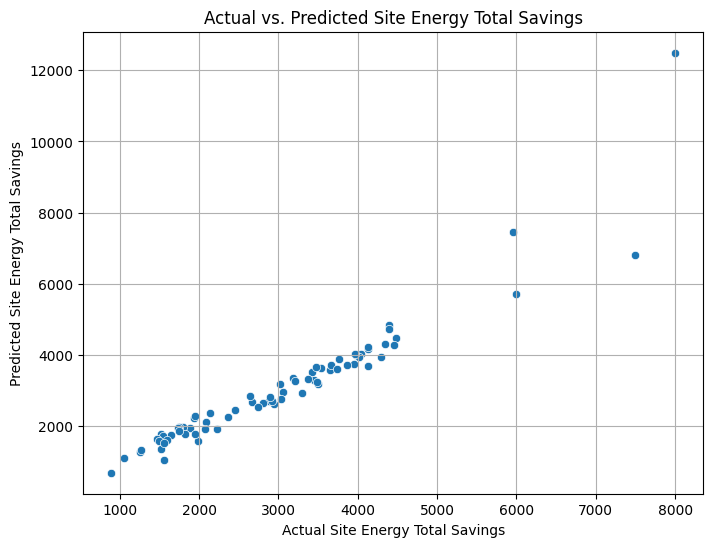

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create scatter plot of actual vs. predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Site Energy Total Savings')
plt.ylabel('Predicted Site Energy Total Savings')
plt.title('Actual vs. Predicted Site Energy Total Savings')
plt.grid(True)
plt.show()

# Create and Fit OLS model

In [ ]:
import statsmodels.api as sm

# Define the target variable and features
target = date_aggregated_df['site_energy_total_savings']
features = date_aggregated_df.drop(columns=['site_energy_total_savings'])

# Identify columns to drop
cols_to_drop = [col for col in features.columns if '_total' in col or '_savings' in col]

# Drop the identified columns from features
features = features.drop(columns=cols_to_drop)

# Add a constant to the features (for the intercept)
features = sm.add_constant(features)

# Create and fit the OLS model
model = sm.OLS(target, features).fit()

# Print the model summary
print(model.summary())


                                OLS Regression Results                               
Dep. Variable:     site_energy_total_savings   R-squared:                       0.923
Model:                                   OLS   Adj. R-squared:                  0.920
Method:                        Least Squares   F-statistic:                     246.8
Date:                       Mon, 01 Dec 2025   Prob (F-statistic):          2.17e-182
Time:                               22:18:33   Log-Likelihood:                -2657.9
No. Observations:                        366   AIC:                             5352.
Df Residuals:                            348   BIC:                             5422.
Df Model:                                 17                                         
Covariance Type:                   nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

# Create and fit Gradient Boosted Regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, explained_variance_score
import numpy as np

# Define the target variable and features (using the same features as before)
target = date_aggregated_df['site_energy_total_savings']
features = date_aggregated_df.drop(columns=['site_energy_total_savings'])

# Identify columns to drop (including individual savings columns)
cols_to_drop = [col for col in features.columns if '_total' in col or '_savings' in col]

# Drop the identified columns from features
features = features.drop(columns=cols_to_drop)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Create a Gradient Boosting Regressor model
gbr_model = GradientBoostingRegressor(random_state=42)

# Fit the model to the training data
gbr_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_gbr = gbr_model.predict(X_test)

# Evaluate the model
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
explained_variance_gbr = explained_variance_score(y_test, y_pred_gbr)


print("Gradient Boosting Regressor Evaluation:")
print(f"MSE: {mse_gbr}")
print(f"RMSE: {rmse_gbr}")
print(f"R-squared: {r2_gbr}")
print(f"MAE: {mae_gbr}")
print(f"Explained Variance Score: {explained_variance_gbr}")

NameError: name 'date_aggregated_df' is not defined

### GBR Analysis plots:

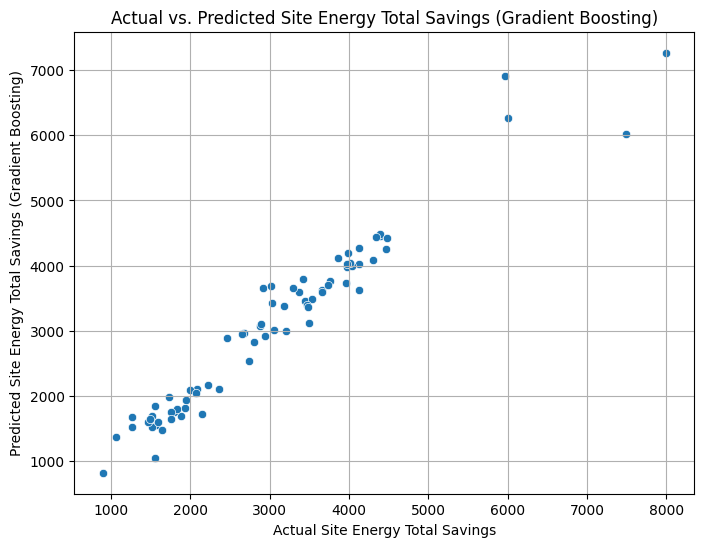

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create scatter plot of actual vs. predicted values for Gradient Boosting
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_gbr)
plt.xlabel('Actual Site Energy Total Savings')
plt.ylabel('Predicted Site Energy Total Savings (Gradient Boosting)')
plt.title('Actual vs. Predicted Site Energy Total Savings (Gradient Boosting)')
plt.grid(True)
plt.show()

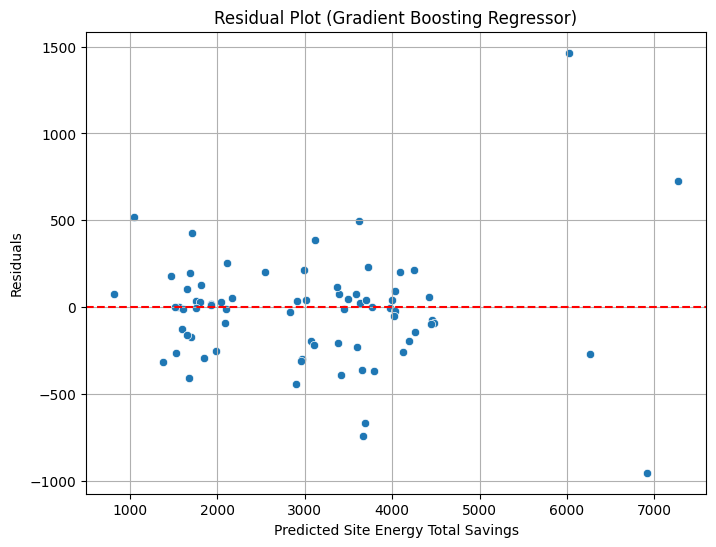

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals_gbr = y_test - y_pred_gbr

# Create a residual plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_gbr, y=residuals_gbr)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at 0
plt.xlabel('Predicted Site Energy Total Savings')
plt.ylabel('Residuals')
plt.title('Residual Plot (Gradient Boosting Regressor)')
plt.grid(True)
plt.show()

In [ ]:
df.head()

,upgrade,timestamp,district_cooling_cooling,district_heating_heating,district_heating_water_systems,electricity_cooling,electricity_exterior_lighting,electricity_fans,electricity_heat_recovery,electricity_heat_rejection,...,electricity_interior_equipment_savings,electricity_interior_lighting_savings,electricity_water_systems_savings,electricity_total_savings,other_fuel_heating_savings,other_fuel_total_savings,other_fuel_water_systems_savings,site_energy_total_savings,date,time
0,1,2018-01-01 00:15:00,9824.484281,191694.637984,61.546144,20345.845528,9404.539749,45079.848858,276.675465,47.759813,...,0.0,0.0,0.000487,-1962.435245,6549.591938,6549.591938,0.0,4587.156693,2018-01-01,00:15:00
1,1,2018-01-01 00:30:00,9561.683954,200894.407966,96.436990,20138.587560,9404.539749,45485.948479,279.427452,47.150135,...,0.0,0.0,0.012570,-2402.043809,7298.013279,7298.013279,0.0,4895.969470,2018-01-01,00:30:00
2,1,2018-01-01 00:45:00,8951.735476,116056.320210,90.257034,17439.510803,9404.539749,33517.397896,178.695529,38.815962,...,0.0,0.0,-0.012034,-2920.356569,8150.314244,8150.314244,0.0,5229.957675,2018-01-01,00:45:00
3,1,2018-01-01 01:00:00,9211.562603,231857.061427,80.668982,19283.724202,9404.539749,47136.230659,279.427452,42.194914,...,0.0,0.0,0.014001,-3635.414112,9158.949168,9158.949168,0.0,5523.535055,2018-01-01,01:00:00
4,1,2018-01-01 01:15:00,9197.578548,224504.842558,86.090169,19204.314903,9404.539749,46473.530461,260.521512,42.799592,...,0.0,0.0,-0.013846,-3716.017852,9378.589453,9378.589453,0.0,5662.571600,2018-01-01,01:15:00


# LSTM Model

## Import and clean date and time data

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## Plot time series data

In [ ]:
# Re-initialize DTdf from the CSV to ensure 'site_energy_total_savings' is present
import pandas as pd
DTdf = pd.read_csv(filepath, parse_dates=['timestamp'])
DTdf['date'] = DTdf['timestamp'].dt.date
DTdf['time'] = DTdf['timestamp'].dt.time
DTdf = DTdf.set_index('timestamp')

# Extract the target variable
y = DTdf['site_energy_total_savings']

# Create a list of columns to exclude from features (X).
# This includes the target column itself, and all other '_total' or '_savings' columns,
# as well as 'date' and 'time' which are object dtypes and should not be features for LSTM.
columns_to_exclude_from_X = ['site_energy_total_savings']

# Add other '_total' or '_savings' columns to the exclusion list
for col in DTdf.columns:
    if col != 'site_energy_total_savings' and ('_total' in col or '_savings' in col):
        columns_to_exclude_from_X.append(col)

# Add 'date' and 'time' to the exclusion list if they exist
if 'date' in DTdf.columns:
    columns_to_exclude_from_X.append('date')
if 'time' in DTdf.columns:
    columns_to_exclude_from_X.append('time')

# Remove potential duplicates from the list (though unlikely with this logic)
columns_to_exclude_from_X = list(set(columns_to_exclude_from_X))

# Create X by dropping the identified columns
X = DTdf.drop(columns=columns_to_exclude_from_X)
sortedDF = df.sort_index()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

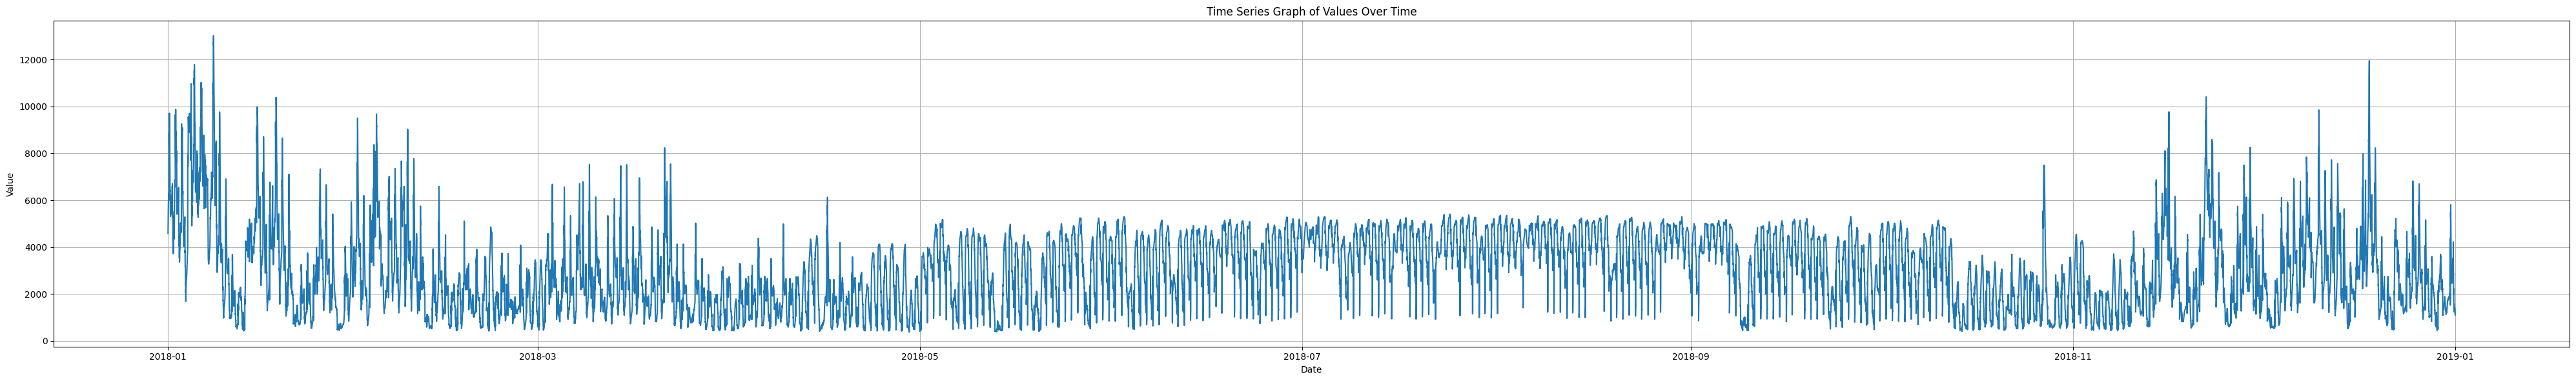

In [ ]:
    plt.figure(figsize=(40, 6)) # Adjust figure size for better readability
    plt.plot(DTdf.index, df['site_energy_total_savings'])
    plt.title('Time Series Graph of Values Over Time')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.grid(True) # Add a grid for easier reading
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

In [ ]:
feature_cols = [col for col in DTdf.columns if col not in ['date','time']]
target_cols = feature_cols  # full autoregressive multivariate model
scaler = MinMaxScaler()
scaled = scaler.fit_transform(DTdf[feature_cols])
scaled_df = pd.DataFrame(scaled, index=DTdf.index, columns=feature_cols)

In [ ]:
def create_sequences(data, window_size=24):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])  # predict next step
    return np.array(X), np.array(y)

window = 24  # lookback = 24 timesteps (~6 hours for 15min sampling)
X, y = create_sequences(scaled_df.values, window)


In [ ]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(y.shape[1])   # matches number of output features
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        83,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 35)             │         1,155 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 278,531 (1.06 MB)

 Trainable params: 278,531 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
stop = EarlyStopping(
    patience=10, monitor='val_loss', restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    batch_size=32,
    callbacks=[stop],
    verbose=1
)


Epoch 1/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - loss: 0.0373 - val_loss: 0.0048
Epoch 2/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - loss: 0.0083 - val_loss: 0.0034
Epoch 3/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - loss: 0.0063 - val_loss: 0.0028
Epoch 4/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0052 - val_loss: 0.0026
Epoch 5/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 0.0045 - val_loss: 0.0025
Epoch 6/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - loss: 0.0043 - val_loss: 0.0023
Epoch 7/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 0.0041 - val_loss: 0.0021
Epoch 8/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0041 - val_loss: 0.0020
Epoch 9/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0040 - val_loss: 0.0022
Epoch 10/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 0.0039 - val_loss: 0.0020
Epoch 11/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - loss: 0.0039 - val_loss: 0.0020
Epoch 12/200
876/87

### Define Forecast Function

In [ ]:
def forecast(model, last_sequence, steps=12):  # 48 = next 12 hours
    seq = last_sequence.copy()
    predictions = []

    for _ in range(steps):
        pred = model.predict(seq.reshape(1, seq.shape[0], seq.shape[1]), verbose=0)
        predictions.append(pred[0])

        # autoregressive: append prediction, drop first element
        seq = np.vstack([seq[1:], pred])

    return np.array(predictions)

## Predict and Plot normal LSTM

In [ ]:
# last window of real data
last_seq = scaled_df.values[-window:]
scaled_forecast = forecast(model, last_seq, steps=10000)

In [ ]:
forecast_df = pd.DataFrame(
    scaler.inverse_transform(scaled_forecast),
    columns=feature_cols
)

forecast_df.index = pd.date_range(
    start=scaled_df.index[-1] + pd.Timedelta(minutes=15),
    periods=len(forecast_df),
    freq="15min"
)

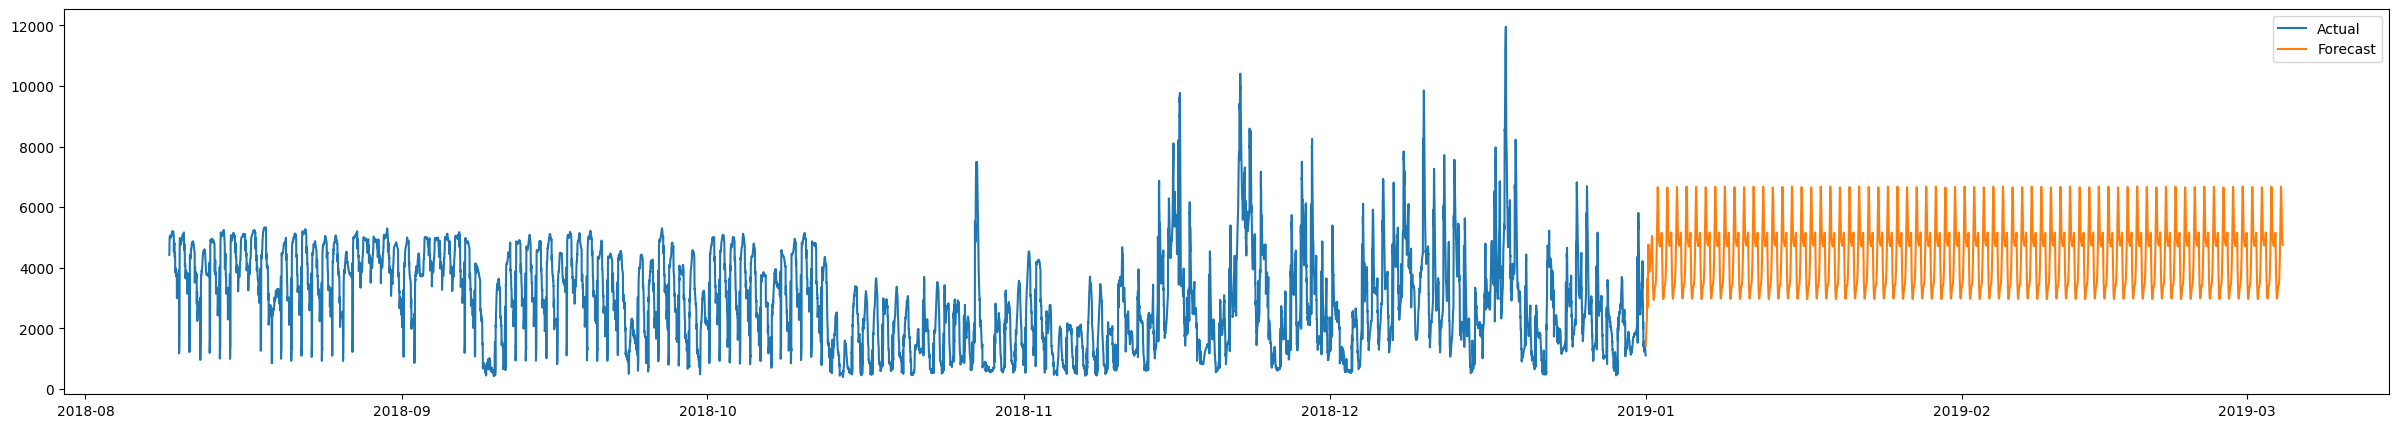

In [ ]:
target_col = 'site_energy_total_savings'

plt.figure(figsize=(30,5))
plt.plot(DTdf['site_energy_total_savings'].iloc[-13900:], label="Actual")
plt.plot(forecast_df[target_col].iloc[:6000], label="Forecast")
plt.legend()
plt.show()

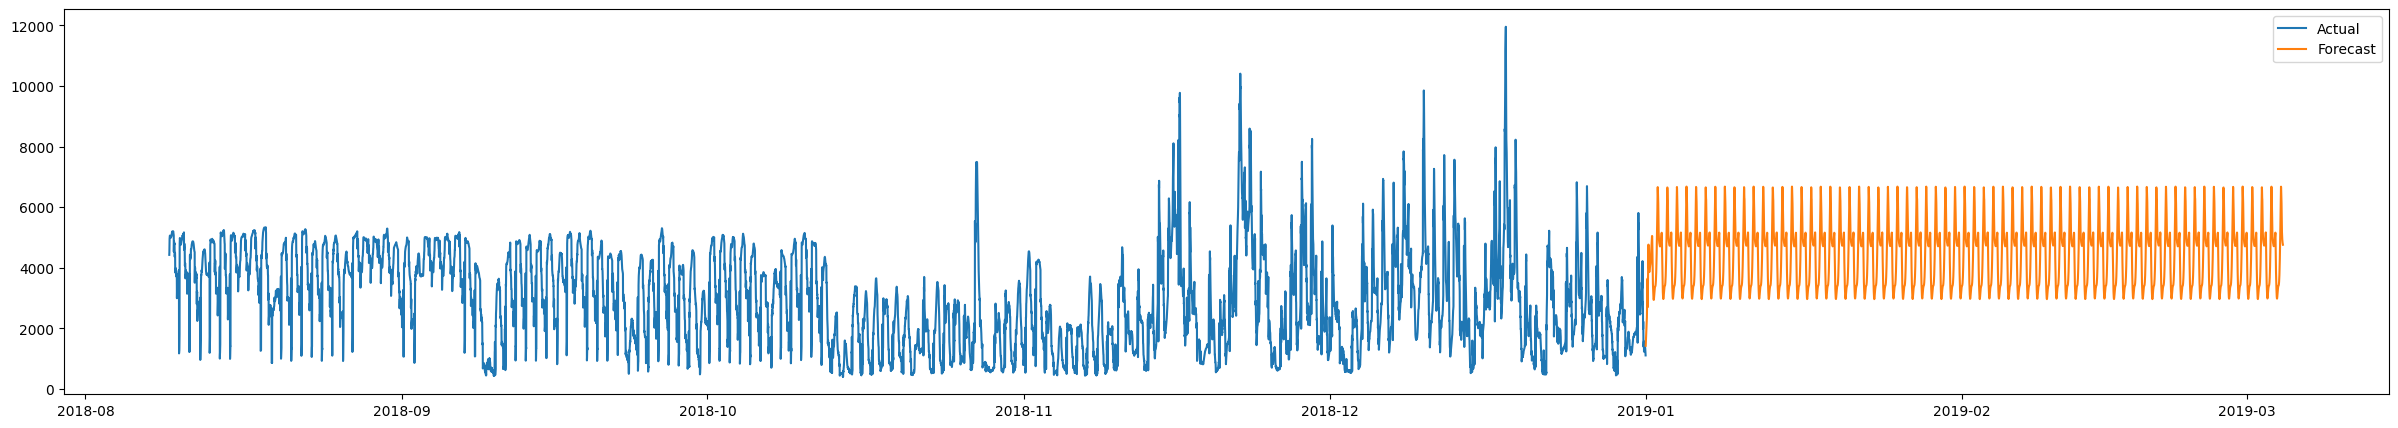

# Cyclical LSTM
Add cyclical temporal features ('hour_of_day', 'day_of_week') to the `DTdf` DataFrame

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
DTdf = pd.read_csv(filepath, parse_dates=['timestamp'])
DTdf['date'] = DTdf['timestamp'].dt.date
DTdf['time'] = DTdf['timestamp'].dt.time
DTdf = DTdf.set_index('timestamp')

# 1. Extract hour_of_day
DTdf['hour_of_day'] = DTdf.index.hour

# 2. Extract day_of_week
DTdf['day_of_week'] = DTdf.index.dayofweek

# 3. Apply sine and cosine transformations to 'hour_of_day'
# Hours range from 0 to 23, so the period is 24
DTdf['hour_of_day_sin'] = np.sin(2 * np.pi * DTdf['hour_of_day'] / 24)
DTdf['hour_of_day_cos'] = np.cos(2 * np.pi * DTdf['hour_of_day'] / 24)

# 4. Apply sine and cosine transformations to 'day_of_week'
# Days of week range from 0 to 6, so the period is 7
DTdf['day_of_week_sin'] = np.sin(2 * np.pi * DTdf['day_of_week'] / 7)
DTdf['day_of_week_cos'] = np.cos(2 * np.pi * DTdf['day_of_week'] / 7)

# 5. Display the first few rows of the updated DTdf
display(DTdf.head())

,upgrade,district_cooling_cooling,district_heating_heating,district_heating_water_systems,electricity_cooling,electricity_exterior_lighting,electricity_fans,electricity_heat_recovery,electricity_heat_rejection,electricity_heating,...,other_fuel_water_systems_savings,site_energy_total_savings,date,time,hour_of_day,day_of_week,hour_of_day_sin,hour_of_day_cos,day_of_week_sin,day_of_week_cos
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:15:00,1,9824.484281,191694.637984,61.546144,20345.845528,9404.539749,45079.848858,276.675465,47.759813,58074.890100,...,0.0,4587.156693,2018-01-01,00:15:00,0,0,0.000000,1.000000,0.0,1.0
2018-01-01 00:30:00,1,9561.683954,200894.407966,96.436990,20138.587560,9404.539749,45485.948479,279.427452,47.150135,62241.569254,...,0.0,4895.969470,2018-01-01,00:30:00,0,0,0.000000,1.000000,0.0,1.0
2018-01-01 00:45:00,1,8951.735476,116056.320210,90.257034,17439.510803,9404.539749,33517.397896,178.695529,38.815962,59176.009615,...,0.0,5229.957675,2018-01-01,00:45:00,0,0,0.000000,1.000000,0.0,1.0
2018-01-01 01:00:00,1,9211.562603,231857.061427,80.668982,19283.724202,9404.539749,47136.230659,279.427452,42.194914,75391.967180,...,0.0,5523.535055,2018-01-01,01:00:00,1,0,0.258819,0.965926,0.0,1.0
2018-01-01 01:15:00,1,9197.578548,224504.842558,86.090169,19204.314903,9404.539749,46473.530461,260.521512,42.799592,55981.875966,...,0.0,5662.571600,2018-01-01,01:15:00,1,0,0.258819,0.965926,0.0,1.0


In [ ]:

feature_cols = [col for col in DTdf.columns if col not in ['date','time']]
target_cols = feature_cols  # full autoregressive multivariate model
scaler = MinMaxScaler()
scaled = scaler.fit_transform(DTdf[feature_cols])
scaled_df = pd.DataFrame(scaled, index=DTdf.index, columns=feature_cols)


feature_cols_updated = [col for col in DTdf.columns if col not in ['date','time', 'hour_of_day', 'day_of_week']]
target_cols_updated = feature_cols_updated # full autoregressive multivariate model

# Drop rows with NaN values in the relevant feature columns before scaling
DTdf_cleaned = DTdf.dropna(subset=feature_cols_updated)

scaler_updated = MinMaxScaler()
scaled_updated = scaler_updated.fit_transform(DTdf_cleaned[feature_cols_updated])
scaled_df_updated = pd.DataFrame(scaled_updated, index=DTdf_cleaned.index, columns=feature_cols_updated)

def create_sequences(data, window_size=24):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])  # predict next step
    return np.array(X), np.array(y)

window = 24  # lookback = 24 timesteps (~6 hours for 15min sampling)
X_updated, y_updated = create_sequences(scaled_df_updated.values, window)

split_point = int(len(X_updated) * 0.8)
X_train_updated, X_test_updated = X_updated[:split_point], X_updated[split_point:]
y_train_updated, y_test_updated = y_updated[:split_point], y_updated[split_point:]

print(f"Original features shape: {scaled_df.shape[1]}")
print(f"Updated features shape: {scaled_df_updated.shape[1]}")
print(f"X_train_updated shape: {X_train_updated.shape}")
print(f"y_train_updated shape: {y_train_updated.shape}")
print(f"X_test_updated shape: {X_test_updated.shape}")
print(f"y_test_updated shape: {y_test_updated.shape}")

Original features shape: 41
Updated features shape: 39
X_train_updated shape: (28012, 24, 39)
y_train_updated shape: (28012, 39)
X_test_updated shape: (7004, 24, 39)
y_test_updated shape: (7004, 39)


##Initialize Model

In [ ]:
model_updated = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_updated.shape[1], X_updated.shape[2])),
    Dropout(0.2),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(y_updated.shape[1])   # matches number of output features
])

model_updated.compile(optimizer='adam', loss='mse')
model_updated.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 24, 128)        │        86,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 24, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 24, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 39)             │         1,287 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 280,711 (1.07 MB)

 Trainable params: 280,711 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

#Train Model

In [ ]:
stop = EarlyStopping(
    patience=10, monitor='val_loss', restore_best_weights=True)

history = model_updated.fit(
    X_train_updated, y_train_updated,
    validation_data=(X_test_updated, y_test_updated),
    epochs=200,
    batch_size=32,
    callbacks=[stop],
    verbose=1
)

Epoch 1/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 0.0397 - val_loss: 0.0060
Epoch 2/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0100 - val_loss: 0.0042
Epoch 3/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0078 - val_loss: 0.0037
Epoch 4/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0067 - val_loss: 0.0044
Epoch 5/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0061 - val_loss: 0.0029
Epoch 6/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0058 - val_loss: 0.0029
Epoch 7/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0056 - val_loss: 0.0027
Epoch 8/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0056 - val_loss: 0.0025
Epoch 9/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0053 - val_loss: 0.0023
Epoch 10/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0053 - val_loss: 0.0026
Epoch 11/200
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0052 - val_loss: 0.0024
Epoch 12/200
876/87

In [ ]:
def forecast(model, last_sequence, steps=12):  # 48 = next 12 hours
    seq = last_sequence.copy()
    predictions = []

    for _ in range(steps):
        pred = model.predict(seq.reshape(1, seq.shape[0], seq.shape[1]), verbose=0)
        predictions.append(pred[0])

        # autoregressive: append prediction, drop first element
        seq = np.vstack([seq[1:], pred])

    return np.array(predictions)

# last window of real data
last_seq = scaled_df_updated.values[-window:]
scaled_forecast = forecast(model_updated, last_seq, steps=10000)

## Predict and Plot

In [ ]:
forecast_df = pd.DataFrame(
    scaler_updated.inverse_transform(scaled_forecast),
    columns=feature_cols_updated
)

forecast_df.index = pd.date_range(
    start=scaled_df_updated.index[-1] + pd.Timedelta(minutes=15),
    periods=len(forecast_df),
    freq="15min"
)

In [ ]:
forecast_df[target_col].head()

,site_energy_total_savings
2019-01-01 00:15:00,1414.978149
2019-01-01 00:30:00,1543.432007
2019-01-01 00:45:00,1509.580078
2019-01-01 01:00:00,1530.035767
2019-01-01 01:15:00,1492.973267


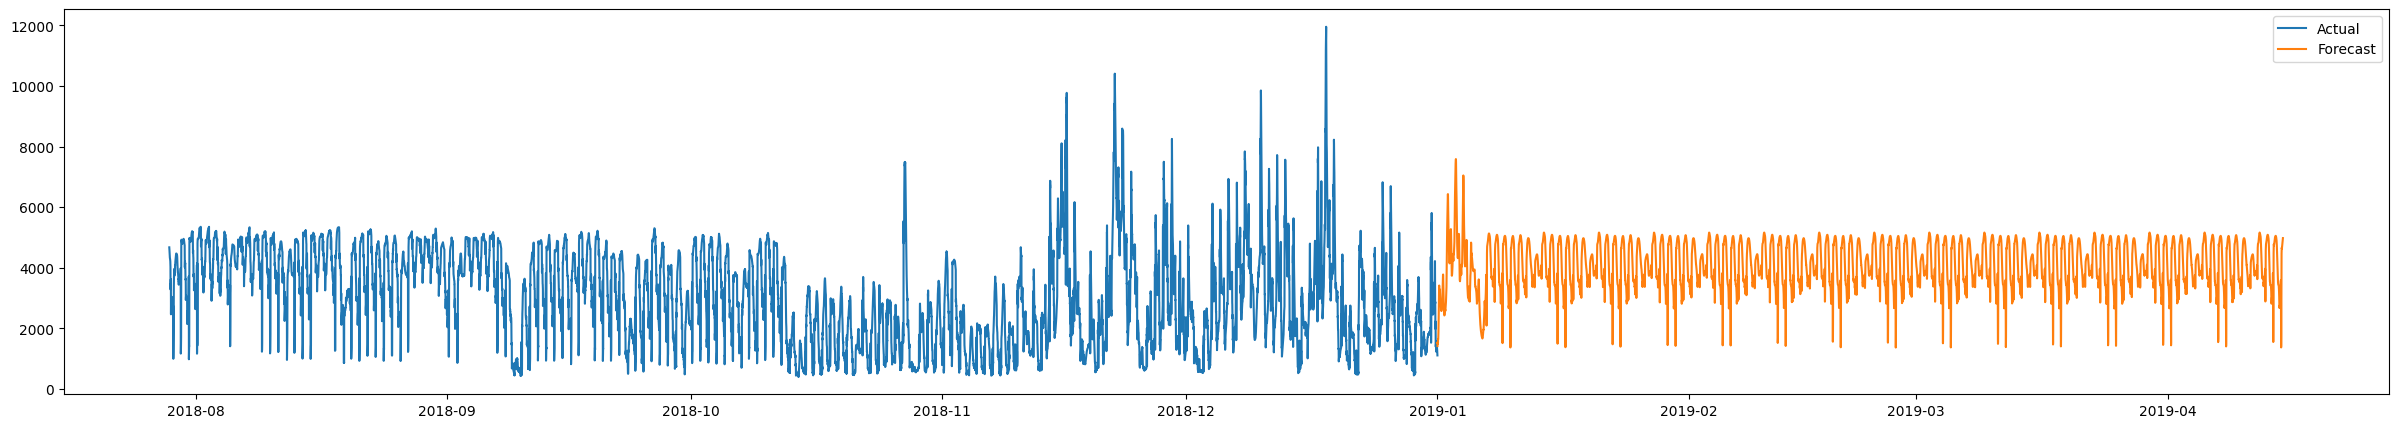

In [ ]:
target_col = 'site_energy_total_savings'

plt.figure(figsize=(30,5))
plt.plot(DTdf['site_energy_total_savings'].iloc[-15000:], label="Actual")
plt.plot(forecast_df[target_col], label="Forecast")
plt.legend()
plt.show()

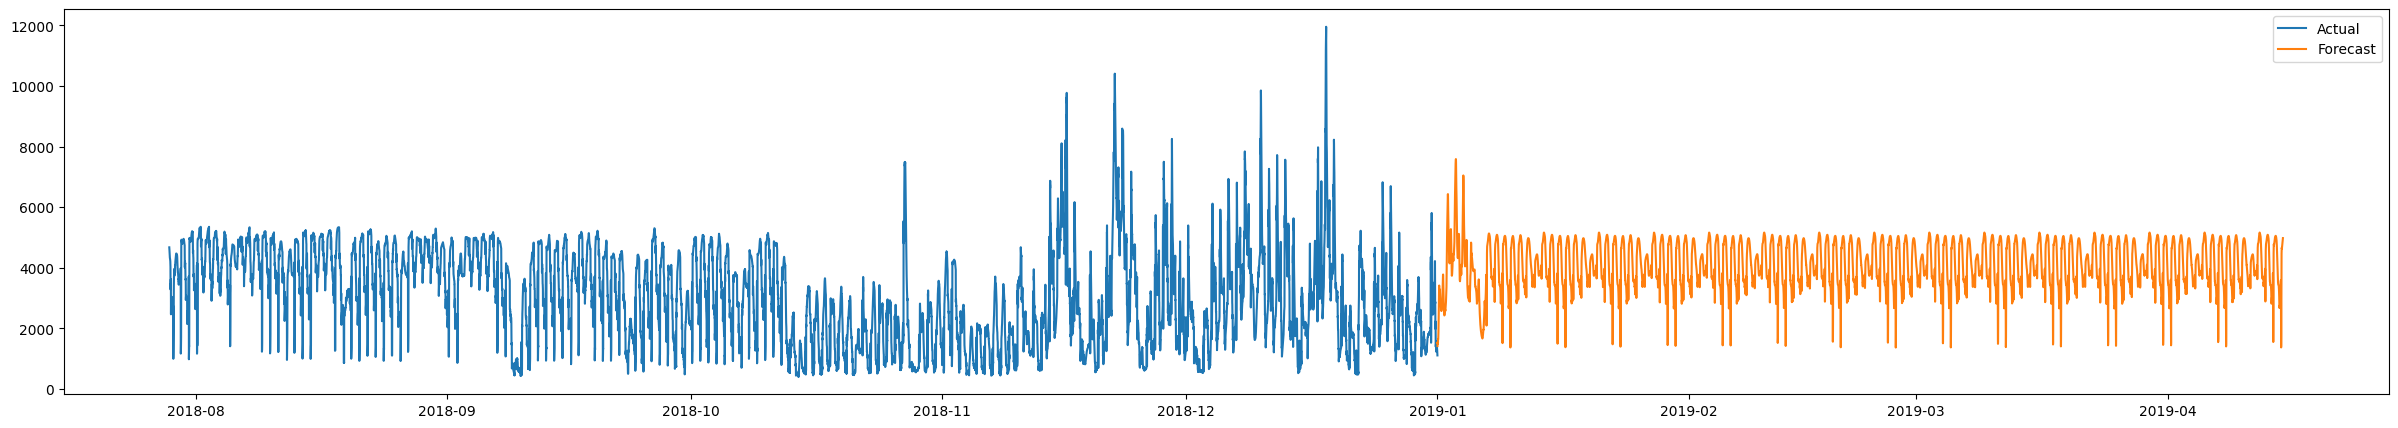